## Car Accident Detection 

In [12]:
# import important library 

import numpy as numpy    
import matplotlib.pyplot as plt     #to plot graph and img
import pandas as pd         
import cv2                # for show the img 
import os               # create path and directory
import warnings                   
warnings.filterwarnings("ignore")

# Load training and validation path

In [7]:
# load training and validation path

train_path = "./archive/custom_dataset/images/train"
val_path = "./archive/custom_dataset/images/val"

#========================================================================
# check if the training and validation paths exist
#========================================================================

if os.path.exists(train_path)and os.path.exists(val_path):
    print("Training and Validation paths exist.")
    print("Training path:", train_path)
    print("Validation path:", val_path)

else:
    print("path not found")

Training and Validation paths exist.
Training path: ./archive/custom_dataset/images/train
Validation path: ./archive/custom_dataset/images/val


# Check the no. of image in datset

----> If number of img less in datset we need to apply imgdatgenrator to create new img that help to reduce overfiting of model

In [8]:
# count the image in train and validation path

train_img = len(os.listdir(train_path))
val_img = len(os.listdir(val_path))

print("Number of training images:", train_img)
print("Number of validation images:", val_img)

Number of training images: 977
Number of validation images: 246


# Here 977 img for train and 246 in validation

-----> That is enough so no need to apply img data genrator

In [ ]:
#========================================================================
# calculate the total number of images
#========================================================================

total_img = train_img + val_img
print("Total number of images:", total_img)

Total number of images: 1223


In [ ]:
# check the types of labels in the yml file

import yaml

#========================================================================
# Load the YAML file
#========================================================================

with open("data.yml", "r") as f:
    data = yaml.safe_load(f)

#========================================================================
# Print all class names
#========================================================================

print("Labels present in the dataset:")
for class_id, class_name in data["names"].items():
    print(f"{class_id}: {class_name}")

Labels present in the dataset:
0: No Accident
1: Minor Accident
2: Moderate Accident
3: Severe Accident
4: Totaled Vehicle


# Labels

* No Accident -
                img without accident or damage 
* Minor Accident -
                small accident
* Moderate Accident -
                accident with medium loss of car 
* Severe Accident-
                High amount of damage car
* Totaled Vehicle -
                Totaly distroy car
                

# check some img size

In [ ]:
image = cv2.imread("./archive/custom_dataset/images/train/3_flip.jpg")

height, width = image.shape[:2]

print(f"Width : {width}")
print(f"Height: {height}")
print(f"Image Size: {width} x {height}")

Width : 275
Height: 183
Image Size: 275 x 183


In [ ]:
image = cv2.imread("./archive/custom_dataset/images/train/11_flip70.jpg")

height, width = image.shape[:2]

print(f"Width : {width}")
print(f"Height: {height}")
print(f"Image Size: {width} x {height}")

Width : 942
Height: 521
Image Size: 942 x 521


In [17]:
import random 

img_path = [f for f in os.listdir(train_path) if f.endswith((".jpg" , ".jpeg", ".png"))]
img_path = random.sample(img_path , 5)

for img in img_path:

    image = cv2.imread(os.path.join(train_path, img))

    height, width = image.shape[:2]

    print("---------------------------------------------------")
    print(f"Width : {width}")
    print(f"Height: {height}")
    print(f"Image Size: {width} x {height}")
    print("---------------------------------------------------")

---------------------------------------------------
Width : 1024
Height: 683
Image Size: 1024 x 683
---------------------------------------------------
---------------------------------------------------
Width : 1280
Height: 720
Image Size: 1280 x 720
---------------------------------------------------
---------------------------------------------------
Width : 1280
Height: 720
Image Size: 1280 x 720
---------------------------------------------------
---------------------------------------------------
Width : 1920
Height: 1080
Image Size: 1920 x 1080
---------------------------------------------------
---------------------------------------------------
Width : 1280
Height: 720
Image Size: 1280 x 720
---------------------------------------------------


# Some plots to understand Data

Images containing each class:
No Accident : 663
Minor Accident : 432
Moderate Accident : 362
Severe Accident : 247
Totaled Vehicle : 318


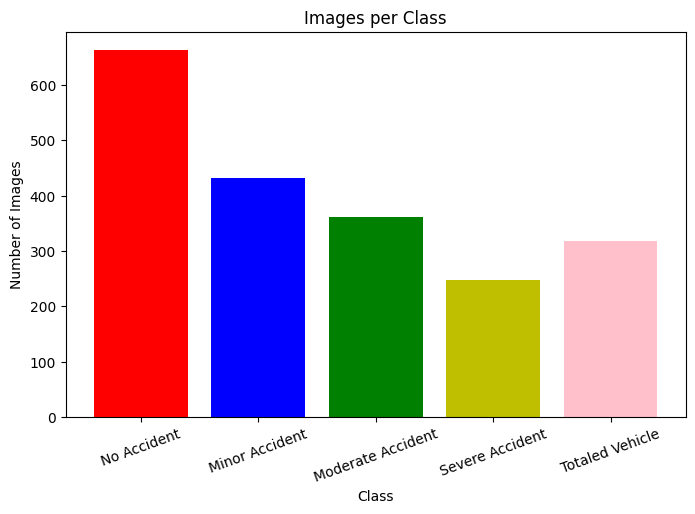

In [ ]:
from collections import Counter

#========================================================================
# Load class names
#========================================================================

with open("data.yml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

label_dirs = [
    "archive/custom_dataset/labels/train",
    "archive/custom_dataset/labels/val"
]

image_count = Counter()

for label_dir in label_dirs:
    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            classes_in_image = set()   # unique classes in this image

            with open(os.path.join(label_dir, file), "r") as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.split()[0])
                        classes_in_image.add(class_id)

            # ---------------------------------------
            # Count the image once for each class present
            # ---------------------------------------
            for cid in classes_in_image:
                image_count[cid] += 1
# ---------------------------------------
# Print counts
# ---------------------------------------
print("Images containing each class:")
for cid in sorted(image_count):
    print(f"{class_names[cid]} : {image_count[cid]}")

#========================================================================
# Bar chart
#========================================================================

labels = [class_names[i] for i in sorted(image_count)]
counts = [image_count[i] for i in sorted(image_count)]

plt.figure(figsize=(8,5))
plt.bar(labels, counts , color=['r' , 'b' , 'g' , 'y' , 'pink'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Images per Class")
plt.xticks(rotation=20)
plt.show()

# Overview of plot

---> Total img is 1223 but here no. of img is more
---> In img so many img present some with accident some without accident therefor in a single img so many type of car counted

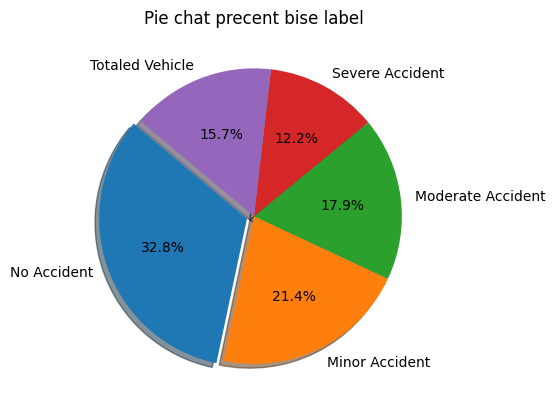

In [ ]:
#Find the percentage of each class in the dataset
#========================================================================

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140 , shadow=True , explode=[0.05 , 0 , 0, 0, 0])
plt.title("Pie chat precent bise label")
plt.show()

# Overview of pie plot

Here maximum img with no accident and least is severe accident 

# See some random images in dataset

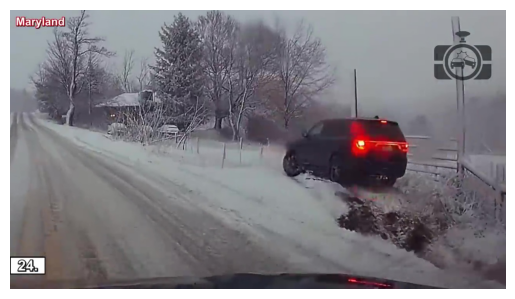

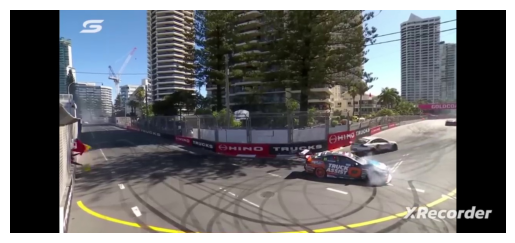

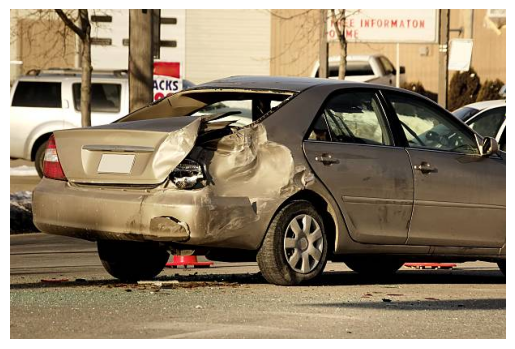

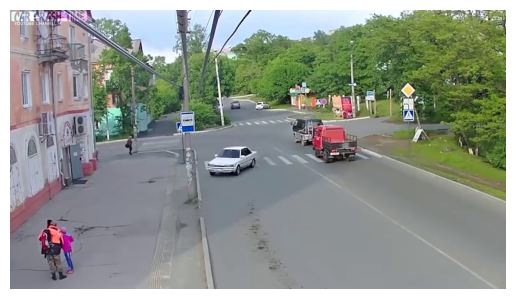

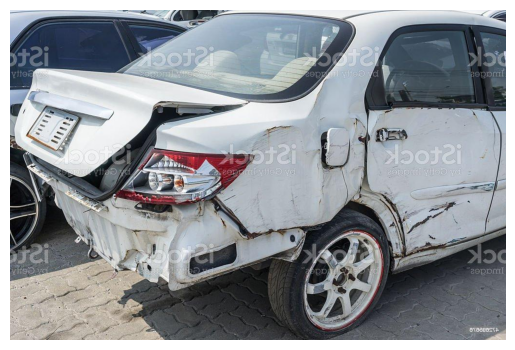

In [14]:
#========================================================================
# see random  images in the train datset
#========================================================================
import random
image_files = [f for f in os.listdir(train_path) if f.endswith((".jpg", ".jpeg", ".png"))]

#========================================================================
# Randomly select 5 images
#========================================================================

selected_images = random.sample(image_files, 5)

#========================================================================
# Print the names of the selected images
#========================================================================
for img in selected_images:
    plt.imshow(plt.imread(os.path.join(train_path, img)))
    plt.axis("off")
    plt.show()

# YOLO TO DETECTRON2 (json) FORMAT -

* this dataset with .txt format and only yolo model support with type to fing best model we need to check with detectron 

# convert the dataset format 

In [ ]:
# import json
# import yaml
# import os
# import cv2

# # ===========================================================
# # CHANGE THIS PATH
# # ===========================================================
# DATASET_ROOT = "./archive/custom_dataset"

# # ===========================================================
# # Read data.yml
# # ===========================================================
# yaml_path = os.path.join("data.yml")

# with open(yaml_path, "r") as f:
#     data = yaml.safe_load(f)

# names = data["names"]

# # -----------------------------------------------------------
# # Handle BOTH list and dict formats
# # -----------------------------------------------------------
# if isinstance(names, dict):
#     class_names = [names[k] for k in sorted(names.keys())]
# else:
#     class_names = names

# print("\nClasses Found:")
# for i, c in enumerate(class_names):
#     print(f"{i}: {c}")

# # ===========================================================
# # Create annotations folder
# # ===========================================================
# annotation_dir = os.path.join(DATASET_ROOT, "annotations")
# os.makedirs(annotation_dir, exist_ok=True)


# def convert(split):

#     image_dir = os.path.join(DATASET_ROOT, "images", split)
#     label_dir = os.path.join(DATASET_ROOT, "labels", split)

#     coco = {
#         "images": [],
#         "annotations": [],
#         "categories": []
#     }

#     # ---------------------------------------
#     # Categories
#     # ---------------------------------------
#     for i, cls in enumerate(class_names):

#         coco["categories"].append({
#             "id": i + 1,
#             "name": str(cls),
#             "supercategory": "none"
#         })

#     image_id = 1
#     annotation_id = 1

#     image_files = sorted([
#         x for x in os.listdir(image_dir)
#         if x.lower().endswith((".jpg", ".jpeg", ".png"))
#     ])

#     for image_name in image_files:

#         image_path = os.path.join(image_dir, image_name)

#         img = cv2.imread(image_path)

#         if img is None:
#             print("Cannot open", image_name)
#             continue

#         h, w = img.shape[:2]

#         coco["images"].append({

#             "id": image_id,

#             "file_name": image_name,

#             "width": w,

#             "height": h

#         })

#         label_path = os.path.join(
#             label_dir,
#             os.path.splitext(image_name)[0] + ".txt"
#         )

#         if os.path.exists(label_path):

#             with open(label_path) as f:

#                 for line in f:

#                     line = line.strip()

#                     if line == "":
#                         continue

#                     cls, xc, yc, bw, bh = map(float, line.split())

#                     cls = int(cls)

#                     if cls >= len(class_names):
#                         print("Invalid class:", cls)
#                         continue

#                     xmin = (xc - bw / 2) * w
#                     ymin = (yc - bh / 2) * h
#                     box_w = bw * w
#                     box_h = bh * h

#                     coco["annotations"].append({

#                         "id": annotation_id,

#                         "image_id": image_id,

#                         "category_id": cls + 1,

#                         "bbox": [
#                             xmin,
#                             ymin,
#                             box_w,
#                             box_h
#                         ],

#                         "area": box_w * box_h,

#                         "iscrowd": 0

#                     })

#                     annotation_id += 1

#         image_id += 1

#     save_json = os.path.join(
#         annotation_dir,
#         f"instances_{split}.json"
#     )

#     with open(save_json, "w") as f:
#         json.dump(coco, f, indent=4)

#     print("\n====================================")
#     print(split.upper())
#     print("Images :", len(coco["images"]))
#     print("Objects:", len(coco["annotations"]))
#     print("Saved  :", save_json)


# convert("train")
# convert("val")

# print("\nConversion Finished Successfully!")


Classes Found:
0: No Accident
1: Minor Accident
2: Moderate Accident
3: Severe Accident
4: Totaled Vehicle

TRAIN
Images : 977
Objects: 2979
Saved  : ./archive/custom_dataset\annotations\instances_train.json

VAL
Images : 246
Objects: 756
Saved  : ./archive/custom_dataset\annotations\instances_val.json

Conversion Finished Successfully!


## FINAL REPORT -

* Datset with 6 classes
* Train has 977 and valid has 246 img 
* Total 1223 images in dataset 
* Every img size is different 
